## <b> Credit Scoring with Decision Tree </b>

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

### <b> Data Peparation </b>

In [2]:
df = pd.read_csv('data/CreditScoring_processed.csv')
print('The Shape of Data:', df.shape)

The Shape of Data: (4455, 14)


In [3]:
df.head()

,Status,Seniority,Home,Time,Age,Marital,Records,Job,Expenses,Income,Assets,Debt,Amount,Price
0,1,9,1,60,30,2,1,3,73,129,0,0,800,846
1,1,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,2,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
3,1,0,1,60,24,1,1,1,63,182,2500,0,900,1325
4,1,0,1,36,26,1,1,1,46,107,0,0,310,910


In [4]:
df.columns = df.columns.str.lower()
df.head().T

,0,1,2,3,4
status,1,1,2,1,1
seniority,9,17,10,0,0
home,1,1,2,1,1
time,60,60,36,60,36
age,30,58,46,24,26
marital,2,3,2,1,1
records,1,1,2,1,1
job,3,1,3,1,1
expenses,73,48,90,63,46
income,129,131,200,182,107


#### <b> Re-encoding the Categorical Variables </b>

Categorical variables are represented by numbers. For converting, we'll use the following map (extracted from [Part1_CredScoring_Processing.R](https://github.com/gastonstat/CreditScoring/blob/master/Part1_CredScoring_Processing.R)). It's code in R which we'll translate to Pandas.

```
levels(dd$Status) = c("good", "bad")
levels(dd$Home) = c("rent", "owner", "priv", "ignore", "parents", "other")
levels(dd$Marital) = c("single", "married", "widow", "separated", "divorced")
levels(dd$Records) = c("no_rec", "yes_rec")
levels(dd$Job) = c("fixed", "partime", "freelance", "others")
```

Let's convert it:

In [5]:
df.status.value_counts()

status
1    3200
2    1254
0       1
Name: count, dtype: int64

In [6]:
status_values = {
    1: 'ok',
    2: 'default',
    0: 'unknown'
}

In [7]:
df.status = df.status.map(status_values)
df.head().T

,0,1,2,3,4
status,ok,ok,default,ok,ok
seniority,9,17,10,0,0
home,1,1,2,1,1
time,60,60,36,60,36
age,30,58,46,24,26
marital,2,3,2,1,1
records,1,1,2,1,1
job,3,1,3,1,1
expenses,73,48,90,63,46
income,129,131,200,182,107


In [8]:
home_values = {
    1: 'rent',
    2: 'owner',
    3: 'private',
    4: 'ignore',
    5: 'parents',
    6: 'other',
    0: 'unknown'
}

df.home = df.home.map(home_values)

In [9]:
marital_values = {
    1: 'single',
    2: 'married',
    3: 'widow',
    4: 'separated',
    5: 'divorced',
    0: 'unknown'
}

df.marital = df.marital.map(marital_values)

In [10]:
record_values = {
    1: 'no',
    2: 'yes',
    0: 'unknown'
}

df.records = df.records.map(record_values)

In [11]:
job_values = {
    1: 'fixed',
    2: 'partime',
    3: 'freelance',
    4: 'others',
    0: 'unknown'
}

df.job = df.job.map(job_values)

In [12]:
df.head().T

,0,1,2,3,4
status,ok,ok,default,ok,ok
seniority,9,17,10,0,0
home,rent,rent,owner,rent,rent
time,60,60,36,60,36
age,30,58,46,24,26
marital,married,widow,married,single,single
records,no,no,yes,no,no
job,freelance,fixed,freelance,fixed,fixed
expenses,73,48,90,63,46
income,129,131,200,182,107


- After these steps, all the categorical variables now have string values and not numbers.

#### <b> Missing Values </b>

- Let's address the missing values.

In [13]:
df.describe().round()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0
mean,8.0,46.0,37.0,56.0,763317.0,1060341.0,404382.0,1039.0,1463.0
std,8.0,15.0,11.0,20.0,8703625.0,10217569.0,6344253.0,475.0,628.0
min,0.0,6.0,18.0,35.0,0.0,0.0,0.0,100.0,105.0
25%,2.0,36.0,28.0,35.0,80.0,0.0,0.0,700.0,1118.0
50%,5.0,48.0,36.0,51.0,120.0,3500.0,0.0,1000.0,1400.0
75%,12.0,60.0,45.0,72.0,166.0,6000.0,0.0,1300.0,1692.0
max,48.0,72.0,68.0,180.0,99999999.0,99999999.0,99999999.0,5000.0,11140.0


- It’s visible that ‘income,’ ‘assets,’ and ‘debt’ columns contain extremely large values (e.g., 99999999.0) as maximum values.
- To address this issue, we need to replace these outlier values. Let’s explore the replacement process.

In [14]:
for c in ['income', 'assets', 'debt']:
    df[c] = df[c].replace(to_replace=99999999, value=np.nan)

In [15]:
df.isnull().sum()

status        0
seniority     0
home          0
time          0
age           0
marital       0
records       0
job           0
expenses      0
income       34
assets       47
debt         18
amount        0
price         0
dtype: int64

- Now the <b>stats</b> are more meaningful

In [16]:
df.describe().round()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4455.0,4455.0,4455.0,4455.0,4421.0,4408.0,4437.0,4455.0,4455.0
mean,8.0,46.0,37.0,56.0,131.0,5403.0,343.0,1039.0,1463.0
std,8.0,15.0,11.0,20.0,86.0,11573.0,1246.0,475.0,628.0
min,0.0,6.0,18.0,35.0,0.0,0.0,0.0,100.0,105.0
25%,2.0,36.0,28.0,35.0,80.0,0.0,0.0,700.0,1118.0
50%,5.0,48.0,36.0,51.0,120.0,3000.0,0.0,1000.0,1400.0
75%,12.0,60.0,45.0,72.0,165.0,6000.0,0.0,1300.0,1692.0
max,48.0,72.0,68.0,180.0,959.0,300000.0,30000.0,5000.0,11140.0


- Next: Let's look at the <b>target</b> variable

In [17]:
df.status.value_counts()

status
ok         3200
default    1254
unknown       1
Name: count, dtype: int64

There's one record for which the status is unknown. Let's remove it - it's not useful for us

In [18]:
df[df.status == 'unknown']

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
3309,unknown,10,private,60,25,single,no,fixed,35,148.0,3000.0,0.0,1500,1888


In [19]:
df = df[df.status != 'unknown'].reset_index(drop=True)

In [20]:
df.isnull().sum()

status        0
seniority     0
home          0
time          0
age           0
marital       0
records       0
job           0
expenses      0
income       34
assets       47
debt         18
amount        0
price         0
dtype: int64

In [21]:
df

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,rent,60,30,married,no,freelance,73,129.0,0.0,0.0,800,846
1,ok,17,rent,60,58,widow,no,fixed,48,131.0,0.0,0.0,1000,1658
2,default,10,owner,36,46,married,yes,freelance,90,200.0,3000.0,0.0,2000,2985
3,ok,0,rent,60,24,single,no,fixed,63,182.0,2500.0,0.0,900,1325
4,ok,0,rent,36,26,single,no,fixed,46,107.0,0.0,0.0,310,910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4449,default,1,rent,60,39,married,no,fixed,69,92.0,0.0,0.0,900,1020
4450,ok,22,owner,60,46,married,no,fixed,60,75.0,3000.0,600.0,950,1263
4451,default,0,owner,24,37,married,no,partime,60,90.0,3500.0,0.0,500,963
4452,ok,0,rent,48,23,single,no,freelance,49,140.0,0.0,0.0,550,550


### <b> Performing the Train/Validation/Test Split </b>

Preparing the data for <b>training:</b>
* First, do <b>train-validation-test split</b>
* Then, apply <b>one-hot encoding to categorical features</b> and get the feature matrix 

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
df_train_full, df_test = train_test_split(df, test_size=0.2, random_state=42)
df_train, df_val = train_test_split(df_train_full, test_size=0.25, random_state=42, stratify=df_train_full['status'])

In [24]:
len(df), len(df_train_full), len(df_train), len(df_val), len(df_test)

(4454, 3563, 2672, 891, 891)

In [25]:
#df_train_full = df_train_full.reset_index(drop=True)
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [26]:
df_train.status

0            ok
1            ok
2            ok
3            ok
4            ok
         ...   
2667    default
2668         ok
2669         ok
2670    default
2671    default
Name: status, Length: 2672, dtype: str

In [27]:
# assigning target variables 
#y_train_full = (df_train_full.status == 'default').astype('int').values
y_train = (df_train.status == 'default').astype('int').values
y_val = (df_val.status == 'default').astype('int').values
y_test = (df_test.status == 'default').astype('int').values

In [28]:
#del df_train_full['status']
del df_train['status']
del df_val['status']
del df_test['status']

In [29]:
df_train

,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,3,rent,48,33,married,no,freelance,89,291.0,0.0,0.0,900,1041
1,5,owner,24,24,single,no,fixed,35,78.0,6000.0,3000.0,500,2262
2,2,rent,48,19,single,no,freelance,60,246.0,20500.0,0.0,1370,1371
3,3,other,60,27,single,no,fixed,35,184.0,4700.0,700.0,1400,1640
4,7,owner,36,39,married,no,freelance,75,205.0,4000.0,0.0,1300,1439
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2667,0,unknown,48,23,married,no,partime,45,26.0,NaN,NaN,1350,1562
2668,21,rent,36,42,married,no,fixed,74,135.0,450.0,0.0,240,1275
2669,12,rent,60,38,married,no,fixed,96,205.0,3500.0,0.0,1400,1742
2670,0,owner,36,23,single,no,partime,45,122.0,2500.0,0.0,400,400


### <b> Decision Trees </b>


In [30]:
#writing a function that implements this  rule set, and test it with one sample client record.

def assess_risk(client):
    if client['records'] == 'yes':
        if client['job'] == 'parttime':
            return 'default'
        else:
            return 'ok'
    else:
        if client['assets'] > 6000:
            return 'ok'
        else:
            return 'default'

In [31]:
#testing the function on one record

xi = df_train.iloc[0].to_dict()
xi

{'seniority': 3,
 'home': 'rent',
 'time': 48,
 'age': 33,
 'marital': 'married',
 'records': 'no',
 'job': 'freelance',
 'expenses': 89,
 'income': 291.0,
 'assets': 0.0,
 'debt': 0.0,
 'amount': 900,
 'price': 1041}

In [32]:
assess_risk(xi)

'default'

#### <b> Training a Decision Tree </b>

In [33]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score

In [34]:
train_dicts = df_train.fillna(0).to_dict(orient='records')
train_dicts[:5]

[{'seniority': 3,
  'home': 'rent',
  'time': 48,
  'age': 33,
  'marital': 'married',
  'records': 'no',
  'job': 'freelance',
  'expenses': 89,
  'income': 291.0,
  'assets': 0.0,
  'debt': 0.0,
  'amount': 900,
  'price': 1041},
 {'seniority': 5,
  'home': 'owner',
  'time': 24,
  'age': 24,
  'marital': 'single',
  'records': 'no',
  'job': 'fixed',
  'expenses': 35,
  'income': 78.0,
  'assets': 6000.0,
  'debt': 3000.0,
  'amount': 500,
  'price': 2262},
 {'seniority': 2,
  'home': 'rent',
  'time': 48,
  'age': 19,
  'marital': 'single',
  'records': 'no',
  'job': 'freelance',
  'expenses': 60,
  'income': 246.0,
  'assets': 20500.0,
  'debt': 0.0,
  'amount': 1370,
  'price': 1371},
 {'seniority': 3,
  'home': 'other',
  'time': 60,
  'age': 27,
  'marital': 'single',
  'records': 'no',
  'job': 'fixed',
  'expenses': 35,
  'income': 184.0,
  'assets': 4700.0,
  'debt': 700.0,
  'amount': 1400,
  'price': 1640},
 {'seniority': 7,
  'home': 'owner',
  'time': 36,
  'age': 39,
 

In [35]:
dv=DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dicts)
X_train

array([[3.30e+01, 9.00e+02, 0.00e+00, ..., 0.00e+00, 3.00e+00, 4.80e+01],
       [2.40e+01, 5.00e+02, 6.00e+03, ..., 0.00e+00, 5.00e+00, 2.40e+01],
       [1.90e+01, 1.37e+03, 2.05e+04, ..., 0.00e+00, 2.00e+00, 4.80e+01],
       ...,
       [3.80e+01, 1.40e+03, 3.50e+03, ..., 0.00e+00, 1.20e+01, 6.00e+01],
       [2.30e+01, 4.00e+02, 2.50e+03, ..., 0.00e+00, 0.00e+00, 3.60e+01],
       [2.00e+01, 1.75e+03, 2.50e+03, ..., 0.00e+00, 2.00e+00, 4.80e+01]],
      shape=(2672, 27))

In [36]:
dv.get_feature_names_out()

array(['age', 'amount', 'assets', 'debt', 'expenses', 'home=ignore',
       'home=other', 'home=owner', 'home=parents', 'home=private',
       'home=rent', 'home=unknown', 'income', 'job=fixed',
       'job=freelance', 'job=others', 'job=partime', 'marital=divorced',
       'marital=married', 'marital=separated', 'marital=single',
       'marital=widow', 'price', 'records=no', 'records=yes', 'seniority',
       'time'], dtype=object)

In [37]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [38]:
val_dicts = df_val.fillna(0).to_dict(orient='records')
X_val = dv.transform(val_dicts)
y_pred = dt.predict_proba(X_val)[:, 1]

In [39]:
roc_auc_score(y_val, y_pred)

0.6561129715043912

#### <b> Overfitting </b>

In [40]:
y_pred = dt.predict_proba(X_train)[:, 1]
roc_auc_score(y_train, y_pred)

0.999999648206168

In [41]:
dt = DecisionTreeClassifier(max_depth=3)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [42]:
y_pred = dt.predict_proba(X_train)[:, 1]
auc = roc_auc_score(y_train, y_pred)
print('train', auc)

train 0.7729262281298569


In [43]:
y_pred = dt.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, y_pred)
print('val', auc)

val 0.7420073292474884


#### <b> Decision Stump </b>

In [44]:
dt = DecisionTreeClassifier(max_depth=1)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [45]:
y_pred = dt.predict_proba(X_train)[:, 1]
auc = roc_auc_score(y_train, y_pred)
print('train', auc)

train 0.6219123934856225


In [46]:
y_pred = dt.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, y_pred)
print('val', auc)

val 0.60218929677134


#### <b> Visualizing Decision Stump </b>

In [47]:
from sklearn.tree import export_text
print(export_text(dt))

|--- feature_24 <= 0.50
|   |--- class: 0
|--- feature_24 >  0.50
|   |--- class: 1



In [48]:
names = dv.get_feature_names_out().tolist()
print(export_text(dt, feature_names=names))

|--- records=yes <= 0.50
|   |--- class: 0
|--- records=yes >  0.50
|   |--- class: 1



#### <b> Decision Tree with Depth of 2 </b>

In [49]:
dt = DecisionTreeClassifier(max_depth=2)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [50]:
y_pred = dt.predict_proba(X_train)[:, 1]
auc = roc_auc_score(y_train, y_pred)
print('train', auc)

train 0.7272975127472494


In [51]:
y_pred = dt.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, y_pred)
print('val', auc)

val 0.6757787325456499


#### <b> Visualizing Decision Tree </b>

In [52]:
print(export_text(dt))

|--- feature_24 <= 0.50
|   |--- feature_12 <= 96.50
|   |   |--- class: 0
|   |--- feature_12 >  96.50
|   |   |--- class: 0
|--- feature_24 >  0.50
|   |--- feature_25 <= 5.50
|   |   |--- class: 1
|   |--- feature_25 >  5.50
|   |   |--- class: 0



In [53]:
names = dv.get_feature_names_out().tolist()
print(export_text(dt, feature_names=names))

|--- records=yes <= 0.50
|   |--- income <= 96.50
|   |   |--- class: 0
|   |--- income >  96.50
|   |   |--- class: 0
|--- records=yes >  0.50
|   |--- seniority <= 5.50
|   |   |--- class: 1
|   |--- seniority >  5.50
|   |   |--- class: 0



In [54]:
data = [
    [8000, 'default'],
    [2000, 'default'],
    [0, 'default'],
    [5000, 'ok'],
    [5000, 'ok'],
    [4000, 'ok'],
    [9000, 'ok'],
    [3000, 'default']
    
]

In [55]:
df_example = pd.DataFrame(data, columns=['assets', 'status'])
df_example

,assets,status
0,8000,default
1,2000,default
2,0,default
3,5000,ok
4,5000,ok
5,4000,ok
6,9000,ok
7,3000,default


In [56]:
df_example.sort_values('assets')

,assets,status
2,0,default
1,2000,default
7,3000,default
5,4000,ok
3,5000,ok
4,5000,ok
0,8000,default
6,9000,ok


In [57]:
Ts = [0, 2000, 3000, 4000, 5000, 8000]

In [58]:
pip install Ipython

Note: you may need to restart the kernel to use updated packages.


In [59]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [60]:
from IPython.display import display

In [61]:
for T in Ts:
    print(T)
    df_left = df_example[df_example.assets <= T]
    df_right = df_example[df_example.assets > T]

    display(df_left)
    display(df_right)

    print()

0


,assets,status
2,0,default


,assets,status
0,8000,default
1,2000,default
3,5000,ok
4,5000,ok
5,4000,ok
6,9000,ok
7,3000,default



2000


,assets,status
1,2000,default
2,0,default


,assets,status
0,8000,default
3,5000,ok
4,5000,ok
5,4000,ok
6,9000,ok
7,3000,default



3000


,assets,status
1,2000,default
2,0,default
7,3000,default


,assets,status
0,8000,default
3,5000,ok
4,5000,ok
5,4000,ok
6,9000,ok



4000


,assets,status
1,2000,default
2,0,default
5,4000,ok
7,3000,default


,assets,status
0,8000,default
3,5000,ok
4,5000,ok
6,9000,ok



5000


,assets,status
1,2000,default
2,0,default
3,5000,ok
4,5000,ok
5,4000,ok
7,3000,default


,assets,status
0,8000,default
6,9000,ok



8000


,assets,status
0,8000,default
1,2000,default
2,0,default
3,5000,ok
4,5000,ok
5,4000,ok
7,3000,default


,assets,status
6,9000,ok


In [62]:
T = 4000
df_left = df_example[df_example.assets <= T]
df_right = df_example[df_example.assets > T]

display(df_left)
display(df_right)

,assets,status
1,2000,default
2,0,default
5,4000,ok
7,3000,default


,assets,status
0,8000,default
3,5000,ok
4,5000,ok
6,9000,ok


In [63]:
T = 4000
df_left = df_example[df_example.assets <= T]
df_right = df_example[df_example.assets > T]

display(df_left)
print(df_left.status.value_counts(normalize=True))
display(df_right)
print(df_right.status.value_counts(normalize=True))

,assets,status
1,2000,default
2,0,default
5,4000,ok
7,3000,default


status
default    0.75
ok         0.25
Name: proportion, dtype: float64


,assets,status
0,8000,default
3,5000,ok
4,5000,ok
6,9000,ok


status
ok         0.75
default    0.25
Name: proportion, dtype: float64


In [64]:
for T in Ts:
    print(T)
    df_left = df_example[df_example.assets <= T]
    df_right = df_example[df_example.assets > T]

    display(df_left)
    print(df_left.status.value_counts(normalize=True))
    display(df_right)
    print(df_right.status.value_counts(normalize=True))

    print()

0


,assets,status
2,0,default


status
default    1.0
Name: proportion, dtype: float64


,assets,status
0,8000,default
1,2000,default
3,5000,ok
4,5000,ok
5,4000,ok
6,9000,ok
7,3000,default


status
ok         0.571429
default    0.428571
Name: proportion, dtype: float64

2000


,assets,status
1,2000,default
2,0,default


status
default    1.0
Name: proportion, dtype: float64


,assets,status
0,8000,default
3,5000,ok
4,5000,ok
5,4000,ok
6,9000,ok
7,3000,default


status
ok         0.666667
default    0.333333
Name: proportion, dtype: float64

3000


,assets,status
1,2000,default
2,0,default
7,3000,default


status
default    1.0
Name: proportion, dtype: float64


,assets,status
0,8000,default
3,5000,ok
4,5000,ok
5,4000,ok
6,9000,ok


status
ok         0.8
default    0.2
Name: proportion, dtype: float64

4000


,assets,status
1,2000,default
2,0,default
5,4000,ok
7,3000,default


status
default    0.75
ok         0.25
Name: proportion, dtype: float64


,assets,status
0,8000,default
3,5000,ok
4,5000,ok
6,9000,ok


status
ok         0.75
default    0.25
Name: proportion, dtype: float64

5000


,assets,status
1,2000,default
2,0,default
3,5000,ok
4,5000,ok
5,4000,ok
7,3000,default


status
default    0.5
ok         0.5
Name: proportion, dtype: float64


,assets,status
0,8000,default
6,9000,ok


status
default    0.5
ok         0.5
Name: proportion, dtype: float64

8000


,assets,status
0,8000,default
1,2000,default
2,0,default
3,5000,ok
4,5000,ok
5,4000,ok
7,3000,default


status
default    0.571429
ok         0.428571
Name: proportion, dtype: float64


,assets,status
6,9000,ok


status
ok    1.0
Name: proportion, dtype: float64



In [65]:
data = [
    [8000, 3000, 'default'],
    [2000, 1000, 'default'],
    [0, 1000, 'default'],
    [5000, 1000, 'ok'],
    [5000, 1000, 'ok'],
    [4000, 1000, 'ok'],
    [9000, 500, 'ok'],
    [3000, 2000, 'default']
    
]

In [66]:
df_example = pd.DataFrame(data, columns=['assets', 'debt', 'status'])
df_example

,assets,debt,status
0,8000,3000,default
1,2000,1000,default
2,0,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
6,9000,500,ok
7,3000,2000,default


In [67]:
df_example.sort_values('debt')

,assets,debt,status
6,9000,500,ok
1,2000,1000,default
2,0,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
7,3000,2000,default
0,8000,3000,default


In [68]:
thresholds = {
    'assets':[0, 2000, 3000, 4000, 5000, 8000],
    'debt': [500, 1000, 2000]
}

for feature, Ts in thresholds.items():
    print('--------------------')
    for T in Ts:
        print(T)
        df_left = df_example[df_example[feature] <= T]
        df_right = df_example[df_example[feature] > T]

        display(df_left)
        print(df_left.status.value_counts(normalize=True))
        display(df_right)
        print(df_right.status.value_counts(normalize=True))

        print()
    print('--------------------')

--------------------
0


,assets,debt,status
2,0,1000,default


status
default    1.0
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
1,2000,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
6,9000,500,ok
7,3000,2000,default


status
ok         0.571429
default    0.428571
Name: proportion, dtype: float64

2000


,assets,debt,status
1,2000,1000,default
2,0,1000,default


status
default    1.0
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
6,9000,500,ok
7,3000,2000,default


status
ok         0.666667
default    0.333333
Name: proportion, dtype: float64

3000


,assets,debt,status
1,2000,1000,default
2,0,1000,default
7,3000,2000,default


status
default    1.0
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
6,9000,500,ok


status
ok         0.8
default    0.2
Name: proportion, dtype: float64

4000


,assets,debt,status
1,2000,1000,default
2,0,1000,default
5,4000,1000,ok
7,3000,2000,default


status
default    0.75
ok         0.25
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
3,5000,1000,ok
4,5000,1000,ok
6,9000,500,ok


status
ok         0.75
default    0.25
Name: proportion, dtype: float64

5000


,assets,debt,status
1,2000,1000,default
2,0,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
7,3000,2000,default


status
default    0.5
ok         0.5
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
6,9000,500,ok


status
default    0.5
ok         0.5
Name: proportion, dtype: float64

8000


,assets,debt,status
0,8000,3000,default
1,2000,1000,default
2,0,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
7,3000,2000,default


status
default    0.571429
ok         0.428571
Name: proportion, dtype: float64


,assets,debt,status
6,9000,500,ok


status
ok    1.0
Name: proportion, dtype: float64

--------------------
--------------------
500


,assets,debt,status
6,9000,500,ok


status
ok    1.0
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
1,2000,1000,default
2,0,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
7,3000,2000,default


status
default    0.571429
ok         0.428571
Name: proportion, dtype: float64

1000


,assets,debt,status
1,2000,1000,default
2,0,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
6,9000,500,ok


status
ok         0.666667
default    0.333333
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
7,3000,2000,default


status
default    1.0
Name: proportion, dtype: float64

2000


,assets,debt,status
1,2000,1000,default
2,0,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
6,9000,500,ok
7,3000,2000,default


status
ok         0.571429
default    0.428571
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default


status
default    1.0
Name: proportion, dtype: float64

--------------------


### <b>Decision Trees Parameter Tuning </b>

In [69]:
# using various max_depth
depths = [1, 2, 3, 4, 5, 6, 10, 15, 20, None]

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth)
    dt.fit(X_train, y_train)

    # remember we need the column with negtive score
    y_pred = dt.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)

    print('%4s --> %.3f' % (depth, auc))

   1 --> 0.602
   2 --> 0.676
   3 --> 0.742
   4 --> 0.754
   5 --> 0.769
   6 --> 0.757
  10 --> 0.702
  15 --> 0.658
  20 --> 0.662
None --> 0.656


In [70]:
scores = []

for d in [4, 5, 6]:
    for s in [1, 2, 5, 10, 15, 20, 100, 200, 500]:
        dt = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=s)
        dt.fit(X_train, y_train)

        y_pred = dt.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)

        scores.append((d, s, auc))
        

In [71]:
columns = ['max_depth', 'min_samples_leaf', 'auc']
df_scores = pd.DataFrame(scores, columns=columns)
df_scores.head()

,max_depth,min_samples_leaf,auc
0,4,1,0.659512
1,4,2,0.677090
2,4,5,0.743931
3,4,10,0.788374
4,4,15,0.791006


In [72]:
df_scores.sort_values(by='auc', ascending=False).head()

,max_depth,min_samples_leaf,auc
13,5,15,0.792563
4,4,15,0.791006
22,6,15,0.790842
5,4,20,0.789638
23,6,20,0.789366


In [73]:
# index - rows
df_scores_pivot = df_scores.pivot(index='min_samples_leaf',
                                  columns=['max_depth'],
                                  values=['auc'])

df_scores_pivot.round(3)

auc              
max_depth             4      5      6
min_samples_leaf                     
1                 0.660  0.649  0.665
2                 0.677  0.676  0.663
5                 0.744  0.748  0.749
10                0.788  0.786  0.788
15                0.791  0.793  0.791
20                0.790  0.788  0.789
100               0.777  0.777  0.777
200               0.753  0.753  0.753
500               0.672  0.672  0.672

<Axes: xlabel='None-max_depth', ylabel='min_samples_leaf'>

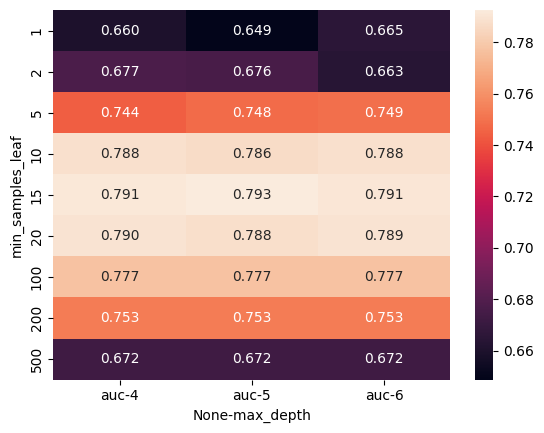

In [74]:
sns.heatmap(df_scores_pivot, annot=True, fmt=".3f")

In [75]:
scores = []

for d in [4, 5, 6, 7, 10, 15, 20, None]:
    for s in [1, 2, 5, 10, 15, 20, 100, 200, 500]:
        dt = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=s)
        dt.fit(X_train, y_train)

        y_pred = dt.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)

        scores.append((d, s, auc))

In [76]:
columns = ['max_depth', 'min_samples_leaf', 'auc']
df_scores = pd.DataFrame(scores, columns=columns)

In [77]:
df_scores.sort_values(by='auc', ascending=False).head()

,max_depth,min_samples_leaf,auc
49,15.0,15,0.792563
40,10.0,15,0.791950
58,20.0,15,0.791786
31,7.0,15,0.790842
4,4.0,15,0.790842


In [78]:
# index - rows
df_scores_pivot = df_scores.pivot(index='min_samples_leaf',
                                  columns=['max_depth'],
                                  values=['auc'])

df_scores_pivot.round(3)

auc                                                 
max_depth           NaN   4.0    5.0    6.0    7.0    10.0   15.0   20.0
min_samples_leaf                                                        
1                 0.663  0.669  0.676  0.656  0.655  0.665  0.648  0.666
2                 0.684  0.668  0.682  0.676  0.684  0.676  0.680  0.659
5                 0.749  0.751  0.747  0.755  0.750  0.750  0.748  0.760
10                0.788  0.787  0.787  0.787  0.790  0.788  0.788  0.790
15                0.790  0.791  0.790  0.790  0.791  0.792  0.793  0.792
20                0.788  0.790  0.788  0.789  0.788  0.789  0.789  0.789
100               0.777  0.777  0.777  0.777  0.777  0.777  0.777  0.777
200               0.753  0.753  0.753  0.753  0.753  0.753  0.753  0.753
500               0.672  0.672  0.672  0.672  0.672  0.672  0.672  0.672

<Axes: xlabel='None-max_depth', ylabel='min_samples_leaf'>

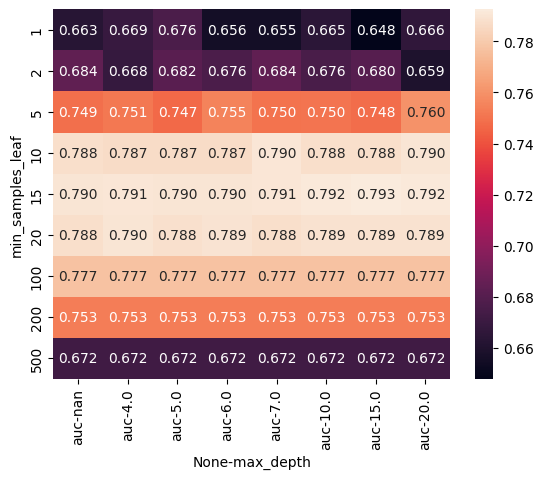

In [79]:
sns.heatmap(df_scores_pivot, annot=True, fmt=".3f")

In [80]:
dt = DecisionTreeClassifier(max_depth=6, min_samples_leaf=15)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",15
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [81]:
print(export_text(dt, feature_names=list(dv.get_feature_names_out())))

|--- records=no <= 0.50
|   |--- seniority <= 5.50
|   |   |--- income <= 43.00
|   |   |   |--- amount <= 1250.00
|   |   |   |   |--- class: 1
|   |   |   |--- amount >  1250.00
|   |   |   |   |--- class: 1
|   |   |--- income >  43.00
|   |   |   |--- assets <= 13500.00
|   |   |   |   |--- amount <= 1585.00
|   |   |   |   |   |--- home=owner <= 0.50
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- home=owner >  0.50
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- amount >  1585.00
|   |   |   |   |   |--- price <= 2420.50
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- price >  2420.50
|   |   |   |   |   |   |--- class: 1
|   |   |   |--- assets >  13500.00
|   |   |   |   |--- class: 0
|   |--- seniority >  5.50
|   |   |--- income <= 106.00
|   |   |   |--- assets <= 5500.00
|   |   |   |   |--- expenses <= 41.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- expenses >  41.50
|   |   |   |   |   |--- amount <= 860.50
|   |   |  

### <b> Random Forest </b>

In [82]:
from sklearn.ensemble import RandomForestClassifier

In [83]:
# n_estimators - number of models we want to use
rf = RandomForestClassifier(n_estimators=10)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [84]:
y_pred =rf.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)

0.8127629999368169

In [85]:
rf.predict_proba(X_val[[0]])

array([[0.8, 0.2]])

In [86]:
rf = RandomForestClassifier(n_estimators=10, random_state=1)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [87]:
y_pred =rf.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)

0.8048050799267075

In [88]:
rf.predict_proba(X_val[[0]])

array([[0.6, 0.4]])

#### <b>Tuning Random Forest </b>

In [89]:
scores = []

for n in range(10, 201, 10):
    rf = RandomForestClassifier(n_estimators=n, random_state=1)
    rf.fit(X_train, y_train)

    y_pred = rf.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)

    scores.append((n, auc))

df_scores = pd.DataFrame(scores, columns=['n_estimators', 'auc'])
df_scores

,n_estimators,auc
0,10,0.804805
1,20,0.825791
2,30,0.836027
3,40,0.838229
4,50,0.835373
5,60,0.837941
6,70,0.838700
7,80,0.840387
8,90,0.840693
9,100,0.841167


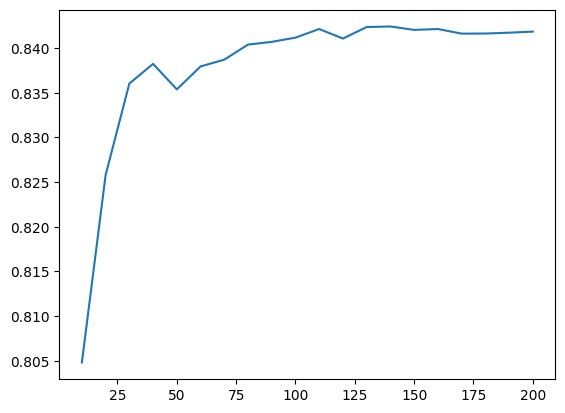

In [90]:
# x-axis - n-estimators
# y-axis - auc score
plt.plot(df_scores.n_estimators, df_scores.auc)

In [91]:
scores = []

for d in [5, 10, 15]:
    for n in range(10, 201, 10):
        rf = RandomForestClassifier(n_estimators=n,
                                max_depth=d,
                                random_state=1)
        rf.fit(X_train, y_train)
        
        y_pred = rf.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
        
        scores.append((d, n, auc))

In [92]:
columns = ['max_depth', 'n_estimators', 'auc']
df_scores = pd.DataFrame(scores, columns=columns)
df_scores.head()

,max_depth,n_estimators,auc
0,5,10,0.806091
1,5,20,0.820636
2,5,30,0.823744
3,5,40,0.826875
4,5,50,0.826850


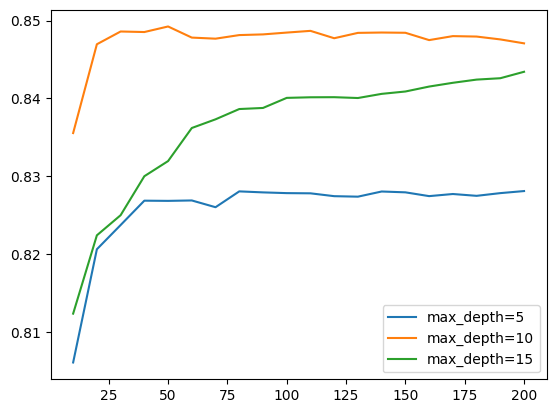

In [93]:
# Let's plot it
for d in [5, 10, 15]:
    df_subset = df_scores[df_scores.max_depth ==d]

    plt.plot(df_subset.n_estimators, 
             df_subset.auc,
             label='max_depth=%d' % d)

plt.legend()

In [94]:
# let's select 10 as the best value
max_depth = 10

scores = []

for s in [1, 3, 5, 10, 50]:
    for n in range(10, 201, 10):
        rf = RandomForestClassifier(n_estimators=n,
                                max_depth=max_depth,
                                min_samples_leaf=s,
                                random_state=1)
        rf.fit(X_train, y_train)
        
        y_pred = rf.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
        
        scores.append((s, n, auc))

In [95]:
columns = ['min_samples_leaf', 'n_estimators', 'auc']
df_scores = pd.DataFrame(scores, columns=columns)
df_scores.head()

,min_samples_leaf,n_estimators,auc
0,1,10,0.835559
1,1,20,0.846967
2,1,30,0.848607
3,1,40,0.848537
4,1,50,0.849251


In [96]:
colors = ['black', 'blue', 'orange', 'red', 'grey']
min_samples_leaf_values = [1, 3, 5, 10, 50]
list(zip(min_samples_leaf_values, colors))

[(1, 'black'), (3, 'blue'), (5, 'orange'), (10, 'red'), (50, 'grey')]

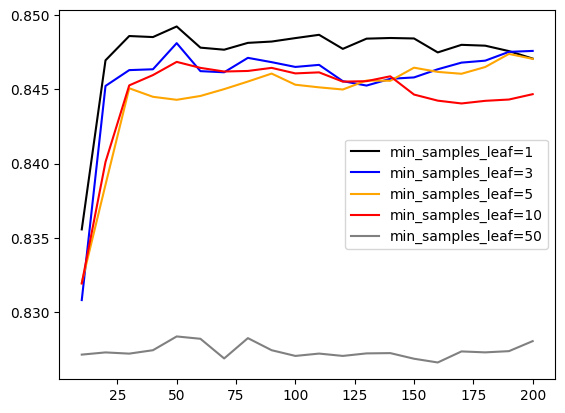

In [97]:
colors = ['black', 'blue', 'orange', 'red', 'grey']
min_samples_leaf_values = [1, 3, 5, 10, 50]

for s, col in zip(min_samples_leaf_values, colors):
    df_subset = df_scores[df_scores.min_samples_leaf == s]

    plt.plot(df_subset.n_estimators, 
             df_subset.auc,
            color=col,
            label='min_samples_leaf=%d' % s)
plt.legend()

In [98]:
# Let's select 3 as the best value
min_samples_leaf = 3

rf = RandomForestClassifier(n_estimators=100,
                            max_depth=max_depth,
                            min_samples_leaf=min_samples_leaf,
                            random_state=1,
                            n_jobs=-1)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

### <b> XGBoost </b>

In [99]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [100]:
import xgboost as xgb

#### <b>Training the first model </b>

In [101]:
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=dv.feature_names_)
dval = xgb.DMatrix(X_val, label=y_val, feature_names = dv.feature_names_)

In [102]:
xgb_params = {
    'eta': 0.3,
    'max_depth': 6,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'nthread': 8,

    'seed': 1,
    'verbosity': 1,
}

In [103]:
model = xgb.train(xgb_params, dtrain, num_boost_round=10)

In [104]:
y_pred = model.predict(dval)
y_pred[:10]

array([0.21185914, 0.11197691, 0.04128111, 0.1843458 , 0.10756837,
       0.7633907 , 0.54824233, 0.05553161, 0.0266088 , 0.4757334 ],
      dtype=float32)

In [105]:
roc_auc_score(y_val, y_pred)

0.8411164465786314

#### <b>Performance Monitoring</b>

In [106]:
watchlist = [(dtrain, 'train'), (dval, 'val')]

In [107]:
xgb_params = {
    'eta': 0.3, 
    'max_depth': 6,
    'min_child_weight': 1,
     
    'objective': 'binary:logistic',
 
    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}
 
model = xgb.train(xgb_params, 
                  dtrain, 
                  num_boost_round=200,
                  evals=watchlist)

[0]	train-logloss:0.50272	val-logloss:0.52371
[1]	train-logloss:0.44780	val-logloss:0.48995
[2]	train-logloss:0.41496	val-logloss:0.46841
[3]	train-logloss:0.38674	val-logloss:0.45264
[4]	train-logloss:0.36708	val-logloss:0.44466
[5]	train-logloss:0.34733	val-logloss:0.44183
[6]	train-logloss:0.33405	val-logloss:0.43742
[7]	train-logloss:0.32248	val-logloss:0.43321
[8]	train-logloss:0.31149	val-logloss:0.43285
[9]	train-logloss:0.30314	val-logloss:0.43083
[10]	train-logloss:0.29601	val-logloss:0.42868
[11]	train-logloss:0.29133	val-logloss:0.42894
[12]	train-logloss:0.28338	val-logloss:0.42575
[13]	train-logloss:0.27657	val-logloss:0.42553
[14]	train-logloss:0.27281	val-logloss:0.42373
[15]	train-logloss:0.26883	val-logloss:0.42483
[16]	train-logloss:0.25972	val-logloss:0.42575
[17]	train-logloss:0.25634	val-logloss:0.42597
[18]	train-logloss:0.24650	val-logloss:0.42623
[19]	train-logloss:0.24101	val-logloss:0.42515
[20]	train-logloss:0.23894	val-logloss:0.42643
[21]	train-logloss:0.23

In [108]:
xgb_params = {
    'eta': 0.3, 
    'max_depth': 6,
    'min_child_weight': 1,
     
    'objective': 'binary:logistic',
     #eval metric to auc:
    'eval_metric': 'auc',
 
    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}
 
model = xgb.train(xgb_params, 
                  dtrain, 
                  num_boost_round=200,
                  evals=watchlist)

[0]	train-auc:0.85860	val-auc:0.78290
[1]	train-auc:0.89329	val-auc:0.81193
[2]	train-auc:0.90184	val-auc:0.82359
[3]	train-auc:0.91277	val-auc:0.83089
[4]	train-auc:0.91849	val-auc:0.83456
[5]	train-auc:0.92828	val-auc:0.83443
[6]	train-auc:0.93524	val-auc:0.83831
[7]	train-auc:0.93839	val-auc:0.83984
[8]	train-auc:0.94326	val-auc:0.83993
[9]	train-auc:0.94595	val-auc:0.84112
[10]	train-auc:0.94857	val-auc:0.84326
[11]	train-auc:0.95071	val-auc:0.84308
[12]	train-auc:0.95415	val-auc:0.84589
[13]	train-auc:0.95703	val-auc:0.84624
[14]	train-auc:0.95830	val-auc:0.84799
[15]	train-auc:0.95981	val-auc:0.84690
[16]	train-auc:0.96376	val-auc:0.84686
[17]	train-auc:0.96481	val-auc:0.84648
[18]	train-auc:0.96905	val-auc:0.84702
[19]	train-auc:0.97125	val-auc:0.84815
[20]	train-auc:0.97183	val-auc:0.84741
[21]	train-auc:0.97254	val-auc:0.84698
[22]	train-auc:0.97296	val-auc:0.84689
[23]	train-auc:0.97438	val-auc:0.84727
[24]	train-auc:0.97498	val-auc:0.84697
[25]	train-auc:0.97545	val-auc:0.84

In [109]:
xgb_params = {
    'eta': 0.3, 
    'max_depth': 6,
    'min_child_weight': 1,
     
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
 
    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}
 
model = xgb.train(xgb_params, 
                  dtrain, 
                  num_boost_round=200,
                  verbose_eval=5,
                  evals=watchlist)

[0]	train-auc:0.85860	val-auc:0.78290
[5]	train-auc:0.92828	val-auc:0.83443
[10]	train-auc:0.94857	val-auc:0.84326
[15]	train-auc:0.95981	val-auc:0.84690
[20]	train-auc:0.97183	val-auc:0.84741
[25]	train-auc:0.97545	val-auc:0.84629
[30]	train-auc:0.98365	val-auc:0.84357
[35]	train-auc:0.98707	val-auc:0.84115
[40]	train-auc:0.99075	val-auc:0.83929
[45]	train-auc:0.99344	val-auc:0.83900
[50]	train-auc:0.99535	val-auc:0.83723
[55]	train-auc:0.99604	val-auc:0.83691
[60]	train-auc:0.99754	val-auc:0.83618
[65]	train-auc:0.99858	val-auc:0.83660
[70]	train-auc:0.99918	val-auc:0.83431
[75]	train-auc:0.99948	val-auc:0.83452
[80]	train-auc:0.99961	val-auc:0.83273
[85]	train-auc:0.99977	val-auc:0.83232
[90]	train-auc:0.99994	val-auc:0.83203
[95]	train-auc:0.99997	val-auc:0.82988
[100]	train-auc:0.99997	val-auc:0.82827
[105]	train-auc:0.99998	val-auc:0.82860
[110]	train-auc:0.99999	val-auc:0.82835
[115]	train-auc:0.99999	val-auc:0.82839
[120]	train-auc:1.00000	val-auc:0.82776
[125]	train-auc:1.0000

#### <b>Parsing XGBoost’s Monitoring Output</b>

In [110]:
%%capture output
 
xgb_params = {
    'eta': 0.3, 
    'max_depth': 6,
    'min_child_weight': 1,
     
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
 
    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}
 
model = xgb.train(xgb_params, 
                  dtrain, 
                  num_boost_round=200,
                  verbose_eval=5,
                  evals=watchlist)

In [111]:
s = output.stdout
print(s)

[0]	train-auc:0.85860	val-auc:0.78290
[5]	train-auc:0.92828	val-auc:0.83443
[10]	train-auc:0.94857	val-auc:0.84326
[15]	train-auc:0.95981	val-auc:0.84690
[20]	train-auc:0.97183	val-auc:0.84741
[25]	train-auc:0.97545	val-auc:0.84629
[30]	train-auc:0.98365	val-auc:0.84357
[35]	train-auc:0.98707	val-auc:0.84115
[40]	train-auc:0.99075	val-auc:0.83929
[45]	train-auc:0.99344	val-auc:0.83900
[50]	train-auc:0.99535	val-auc:0.83723
[55]	train-auc:0.99604	val-auc:0.83691
[60]	train-auc:0.99754	val-auc:0.83618
[65]	train-auc:0.99858	val-auc:0.83660
[70]	train-auc:0.99918	val-auc:0.83431
[75]	train-auc:0.99948	val-auc:0.83452
[80]	train-auc:0.99961	val-auc:0.83273
[85]	train-auc:0.99977	val-auc:0.83232
[90]	train-auc:0.99994	val-auc:0.83203
[95]	train-auc:0.99997	val-auc:0.82988
[100]	train-auc:0.99997	val-auc:0.82827
[105]	train-auc:0.99998	val-auc:0.82860
[110]	train-auc:0.99999	val-auc:0.82835
[115]	train-auc:0.99999	val-auc:0.82839
[120]	train-auc:1.00000	val-auc:0.82776
[125]	train-auc:1.0000

In [112]:
s.split('\n')

['[0]\ttrain-auc:0.85860\tval-auc:0.78290',
 '[5]\ttrain-auc:0.92828\tval-auc:0.83443',
 '[10]\ttrain-auc:0.94857\tval-auc:0.84326',
 '[15]\ttrain-auc:0.95981\tval-auc:0.84690',
 '[20]\ttrain-auc:0.97183\tval-auc:0.84741',
 '[25]\ttrain-auc:0.97545\tval-auc:0.84629',
 '[30]\ttrain-auc:0.98365\tval-auc:0.84357',
 '[35]\ttrain-auc:0.98707\tval-auc:0.84115',
 '[40]\ttrain-auc:0.99075\tval-auc:0.83929',
 '[45]\ttrain-auc:0.99344\tval-auc:0.83900',
 '[50]\ttrain-auc:0.99535\tval-auc:0.83723',
 '[55]\ttrain-auc:0.99604\tval-auc:0.83691',
 '[60]\ttrain-auc:0.99754\tval-auc:0.83618',
 '[65]\ttrain-auc:0.99858\tval-auc:0.83660',
 '[70]\ttrain-auc:0.99918\tval-auc:0.83431',
 '[75]\ttrain-auc:0.99948\tval-auc:0.83452',
 '[80]\ttrain-auc:0.99961\tval-auc:0.83273',
 '[85]\ttrain-auc:0.99977\tval-auc:0.83232',
 '[90]\ttrain-auc:0.99994\tval-auc:0.83203',
 '[95]\ttrain-auc:0.99997\tval-auc:0.82988',
 '[100]\ttrain-auc:0.99997\tval-auc:0.82827',
 '[105]\ttrain-auc:0.99998\tval-auc:0.82860',
 '[110]\tt

In [113]:
line = s.split('\n')[0]
line

'[0]\ttrain-auc:0.85860\tval-auc:0.78290'

In [114]:
line.split('\t')

['[0]', 'train-auc:0.85860', 'val-auc:0.78290']

In [115]:
num_iter, train_auc, val_auc = line.split('\t')
num_iter, train_auc, val_auc

('[0]', 'train-auc:0.85860', 'val-auc:0.78290')

In [116]:
int(num_iter.strip('[]'))

0

In [117]:
float(train_auc.split(':')[1])

0.8586

In [118]:
float(val_auc.split(':')[1])

0.7829

In [119]:
def parse_xgb_output(output):
    results = []

    for line in output.stdout.strip().split('\n'):
        it_line, train_line, val_line = line.split('\t')

        it = int(it_line.strip('[]'))
        train = float(train_line.split(':')[1])
        val = float(val_line.split(':')[1])

        results.append((it, train, val))

    columns = ['num_iter', 'train_auc', 'val_auc']
    df_results = pd.DataFrame(results, columns=columns)

    return df_results

In [120]:
df_score = parse_xgb_output(output)
df_score

,num_iter,train_auc,val_auc
0,0,0.85860,0.78290
1,5,0.92828,0.83443
2,10,0.94857,0.84326
3,15,0.95981,0.84690
4,20,0.97183,0.84741
5,25,0.97545,0.84629
6,30,0.98365,0.84357
7,35,0.98707,0.84115
8,40,0.99075,0.83929
9,45,0.99344,0.83900


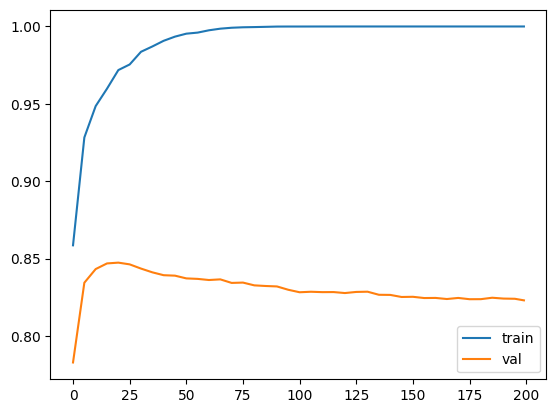

In [121]:
plt.plot(df_score.num_iter, df_score.train_auc, label='train')
plt.plot(df_score.num_iter, df_score.val_auc, label='val')
plt.legend()

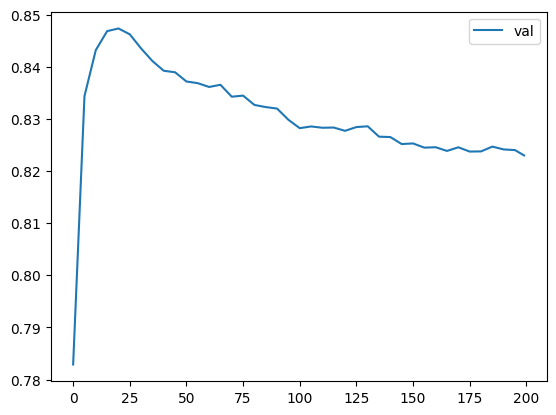

In [122]:
plt.plot(df_score.num_iter, df_score.val_auc, label='val')
plt.legend()

### <b> Parameter Tuning: Eta/Learning Rate </b>

<b> Eta = 0.3</b>

In [123]:
scores = {}

In [124]:
%%capture output

xgb_params = {
    'eta': 0.3,
    'max_depth': 6,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 1,
    'verbosity': 1
}

model = xgb.train(xgb_params, 
                  dtrain, 
                  num_boost_round=200,
                  verbose_eval=5,
                  evals=watchlist)

In [125]:
# structuring keys in the format ‘eta=0.3’ to serve as identifiers in the scores dictionary.
'eta=%s' % (xgb_params['eta'])

'eta=0.3'

In [126]:
key = 'eta=%s' % (xgb_params['eta'])
scores[key] = parse_xgb_output(output)
key

'eta=0.3'

In [127]:
scores

{'eta=0.3':     num_iter  train_auc  val_auc
 0          0    0.85860  0.78290
 1          5    0.92828  0.83443
 2         10    0.94857  0.84326
 3         15    0.95981  0.84690
 4         20    0.97183  0.84741
 5         25    0.97545  0.84629
 6         30    0.98365  0.84357
 7         35    0.98707  0.84115
 8         40    0.99075  0.83929
 9         45    0.99344  0.83900
 10        50    0.99535  0.83723
 11        55    0.99604  0.83691
 12        60    0.99754  0.83618
 13        65    0.99858  0.83660
 14        70    0.99918  0.83431
 15        75    0.99948  0.83452
 16        80    0.99961  0.83273
 17        85    0.99977  0.83232
 18        90    0.99994  0.83203
 19        95    0.99997  0.82988
 20       100    0.99997  0.82827
 21       105    0.99998  0.82860
 22       110    0.99999  0.82835
 23       115    0.99999  0.82839
 24       120    1.00000  0.82776
 25       125    1.00000  0.82848
 26       130    1.00000  0.82863
 27       135    1.00000  0.82664
 28

In [128]:
scores['eta=0.3']

,num_iter,train_auc,val_auc
0,0,0.85860,0.78290
1,5,0.92828,0.83443
2,10,0.94857,0.84326
3,15,0.95981,0.84690
4,20,0.97183,0.84741
5,25,0.97545,0.84629
6,30,0.98365,0.84357
7,35,0.98707,0.84115
8,40,0.99075,0.83929
9,45,0.99344,0.83900


<b> Eta = 1.0 </b>
- setting the eta value to its maximum, which is 1.0.

In [129]:
%%capture output
 
xgb_params = {
    'eta': 1.0, 
    'max_depth': 6,
    'min_child_weight': 1,
     
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
 
    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}
 
model = xgb.train(xgb_params, dtrain, num_boost_round=200,
                  verbose_eval=5,
                  evals=watchlist)

In [130]:
%%capture output

xgb_params = {
    'eta': 1.0,
    'max_depth': 6,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}

model = xgb.train(xgb_params, dtrain, num_boost_round=200, 
                  verbose_eval=5, 
                  evals=watchlist)

In [131]:
key = 'eta=%s' % (xgb_params['eta'])
scores[key] = parse_xgb_output(output)
key

'eta=1.0'

In [132]:
scores['eta=1.0']

,num_iter,train_auc,val_auc
0,0,0.85860,0.78290
1,5,0.95221,0.81591
2,10,0.98488,0.81838
3,15,0.99474,0.81616
4,20,0.99911,0.80529
5,25,0.99952,0.80614
6,30,0.99993,0.80511
7,35,1.00000,0.80761
8,40,1.00000,0.81040
9,45,1.00000,0.81159


<b> Eta = 0.1 </b>
- Repeating the process once more for ‘eta=0.1’ and subsequently print out the dataframe.

In [133]:
%%capture output

xgb_params = {
    'eta': 0.1,
    'max_depth': 6,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
    
}

model = xgb.train(xgb_params, 
                  dtrain, 
                  num_boost_round=200,
                  verbose_eval=5,
                  evals=watchlist)

In [134]:
key = 'eta=%s' % (xgb_params['eta'])
scores[key] = parse_xgb_output(output)
key

'eta=0.1'

In [135]:
scores['eta=0.1']

,num_iter,train_auc,val_auc
0,0,0.85860,0.78290
1,5,0.90248,0.82812
2,10,0.91841,0.83183
3,15,0.93053,0.83874
4,20,0.93827,0.84290
5,25,0.94473,0.84283
6,30,0.95071,0.84432
7,35,0.95536,0.84544
8,40,0.96082,0.84617
9,45,0.96466,0.84469


<b> Eta = 0.05 </b>
- For ‘eta=0.05’ and print out the dataframe.

In [136]:
%%capture output

xgb_params = {
    'eta': 0.05,
    'max_depth': 6,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
    
}

model = xgb.train(xgb_params, 
                  dtrain, 
                  num_boost_round=200,
                  verbose_eval=5,
                  evals=watchlist)

In [137]:
key = 'eta=%s' % (xgb_params['eta'])
scores[key] = parse_xgb_output(output)
key

'eta=0.05'

In [138]:
scores['eta=0.05']

,num_iter,train_auc,val_auc
0,0,0.85860,0.78290
1,5,0.88911,0.81797
2,10,0.90118,0.82499
3,15,0.90816,0.82939
4,20,0.91495,0.83266
5,25,0.92158,0.83552
6,30,0.92700,0.83734
7,35,0.93149,0.83939
8,40,0.93593,0.83976
9,45,0.94028,0.84038


<b> Eta = 0.01 </b>
- Assess the performance for ‘eta=0.01’.

In [139]:
%%capture output

xgb_params = {
    'eta': 0.01,
    'max_depth': 6,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
    
}

model = xgb.train(xgb_params, 
                  dtrain, 
                  num_boost_round=200,
                  verbose_eval=5,
                  evals=watchlist)

In [140]:
key = 'eta=%s' % (xgb_params['eta'])
scores[key] = parse_xgb_output(output)
key

'eta=0.01'

In [141]:
scores['eta=0.01']

,num_iter,train_auc,val_auc
0,0,0.85860,0.78290
1,5,0.87090,0.79857
2,10,0.87693,0.80768
3,15,0.88281,0.81267
4,20,0.88813,0.81788
5,25,0.88969,0.81868
6,30,0.89149,0.82024
7,35,0.89278,0.82073
8,40,0.89542,0.82097
9,45,0.89798,0.82150


### <b> Plotting Eta</b>

In [142]:
scores.keys()

dict_keys(['eta=0.3', 'eta=1.0', 'eta=0.1', 'eta=0.05', 'eta=0.01'])

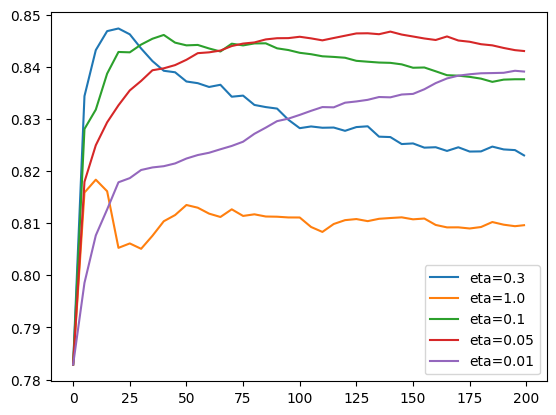

In [143]:
for key, df_score in scores.items():
    plt.plot(df_score.num_iter, df_score.val_auc, label=key)
plt.legend()

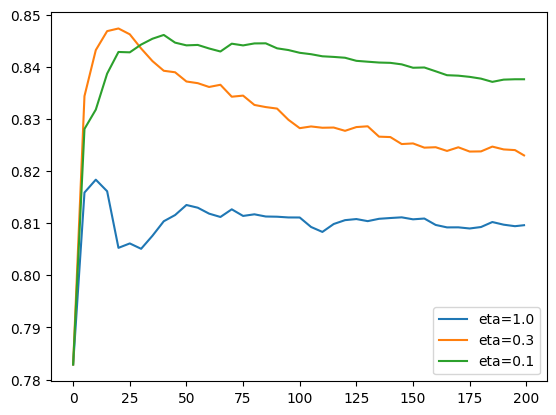

In [144]:
# Concentrate on a few graphs for the initial analysis by plotting three of them: ‘eta=1.0’, ‘eta=0.3’, & ‘eta=0.1’

etas = ['eta=1.0', 'eta=0.3', 'eta=0.1']

for eta in etas:
    df_score = scores[eta]
    plt.plot(df_score.num_iter, df_score.val_auc, label=eta)
plt.legend()

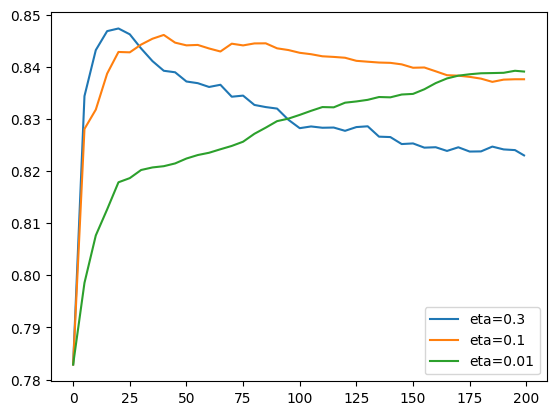

In [145]:
etas = ['eta=0.3', 'eta=0.1', 'eta=0.01']

for eta in etas:
    df_score = scores[eta]
    plt.plot(df_score.num_iter, df_score.val_auc, label=eta)
plt.legend()

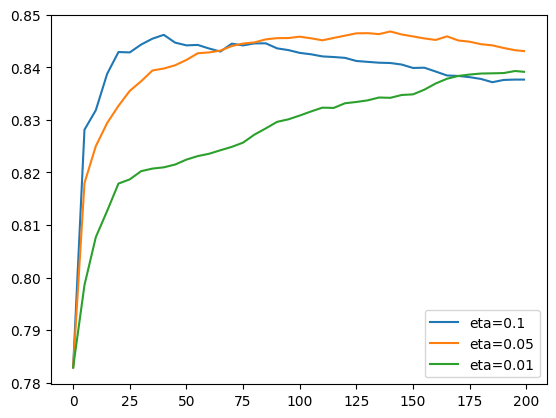

In [146]:
etas = ['eta=0.1', 'eta=0.05', 'eta=0.01']

for eta in etas:
    df_score = scores[eta]
    plt.plot(df_score.num_iter, df_score.val_auc, label=eta)
plt.legend()

### <b> Parameter Tuning: Tuning max_depth</b>

<b> max_depth = 6 </b>

In [147]:
scores = {}

In [148]:
%%capture output

xgb_params = {
    'eta': 0.1,
    'max_depth': 6,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
    
}

model = xgb.train(xgb_params, 
                  dtrain, 
                  num_boost_round=200,
                  verbose_eval=5,
                  evals=watchlist)

In [149]:
key = 'max_depth=%s' % (xgb_params['max_depth'])
scores[key] = parse_xgb_output(output)
key

'max_depth=6'

<b> max_depth = 3 </b>
- setting the ‘max_depth‘ value to 3.

In [150]:
%%capture output

xgb_params = {
    'eta': 0.1,
    'max_depth': 3,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
    
}

model = xgb.train(xgb_params, 
                  dtrain, 
                  num_boost_round=200,
                  verbose_eval=5,
                  evals=watchlist)

In [151]:
key = 'max_depth=%s' % (xgb_params['max_depth'])
scores[key] = parse_xgb_output(output)
key

'max_depth=3'

<b> max_depth = 4 </b>
- repeating the process once more for ‘max_depth=4‘.

In [152]:
%%capture output

xgb_params = {
    'eta': 0.1,
    'max_depth': 4,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
    
}

model = xgb.train(xgb_params, 
                  dtrain, 
                  num_boost_round=200,
                  verbose_eval=5,
                  evals=watchlist)

In [153]:
key = 'max_depth=%s' % (xgb_params['max_depth'])
scores[key] = parse_xgb_output(output)
key

'max_depth=4'

<b> max_depth = 10 </b>
- repeating the process once more for ‘max_depth=10‘.

In [154]:
%%capture output

xgb_params = {
    'eta': 0.1,
    'max_depth': 10,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
    
}

model = xgb.train(xgb_params, 
                  dtrain, 
                  num_boost_round=200,
                  verbose_eval=5,
                  evals=watchlist)

In [155]:
key = 'max_depth=%s' % (xgb_params['max_depth'])
scores[key] = parse_xgb_output(output)
key

'max_depth=10'

### <b> Plotting max_depth</b>

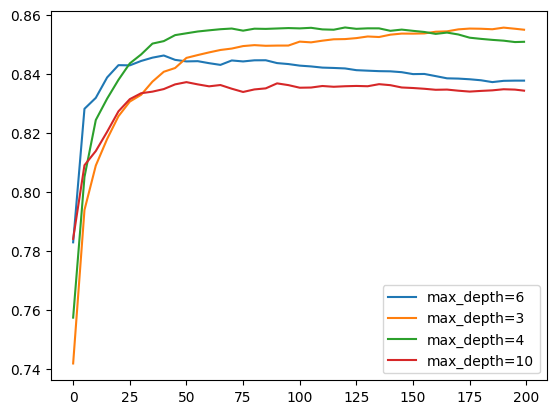

In [156]:
for max_depth, df_score in scores.items():
    plt.plot(df_score.num_iter, df_score.val_auc, label=max_depth)

#plt.ylim(0.8, 0.84)
plt.legend()

In [157]:
del scores['max_depth=10']

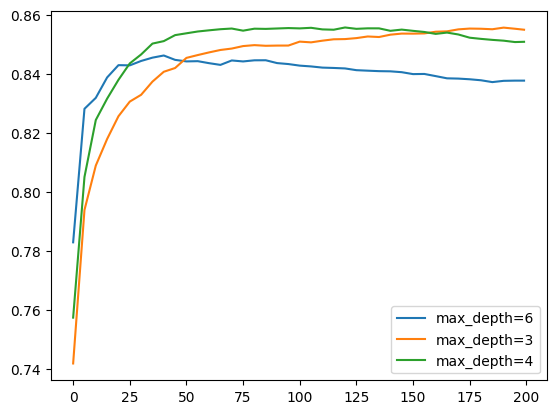

In [158]:
for max_depth, df_score in scores.items():
    plt.plot(df_score.num_iter, df_score.val_auc, label=max_depth)

#plt.ylim(0.8, 0.84)
plt.legend()

### <b> Parameter Tuning: Tuning min_child_weight</b>

<b> min_child_weight = 1 </b>

In [159]:
%%capture output

xgb_params = {
    'eta': 0.1,
    'max_depth': 3,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
    
}

model = xgb.train(xgb_params, 
                  dtrain, 
                  num_boost_round=200,
                  verbose_eval=5,
                  evals=watchlist)

In [160]:
key = 'min_child_weight=%s' % (xgb_params['min_child_weight'])
scores[key] = parse_xgb_output(output)
key

'min_child_weight=1'

<b> min_child_weight = 10 </b>
- setting the ‘min_child_weight‘ value to 10.

In [161]:
%%capture output

xgb_params = {
    'eta': 0.1,
    'max_depth': 3,
    'min_child_weight': 10,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
    
}

model = xgb.train(xgb_params, 
                  dtrain, 
                  num_boost_round=200,
                  verbose_eval=5,
                  evals=watchlist)

In [162]:
key = 'min_child_weight=%s' % (xgb_params['min_child_weight'])
scores[key] = parse_xgb_output(output)
key

'min_child_weight=10'

<b> min_child_weight = 30 </b>
- Repeating the process once more for ‘min_child_weight=30‘.

In [163]:
%%capture output

xgb_params = {
    'eta': 0.1,
    'max_depth': 3,
    'min_child_weight': 30,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
    
}

model = xgb.train(xgb_params, 
                  dtrain, 
                  num_boost_round=200,
                  verbose_eval=5,
                  evals=watchlist)

In [164]:
key = 'min_child_weight=%s' % (xgb_params['min_child_weight'])
scores[key] = parse_xgb_output(output)
key

'min_child_weight=30'

### <b> Plotting min_child_weight</b>

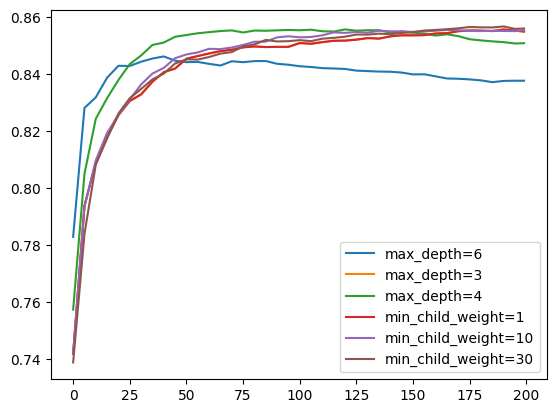

In [165]:
for min_child_weight, df_score in scores.items():
    plt.plot(df_score.num_iter, df_score.val_auc, label=min_child_weight)

plt.legend()

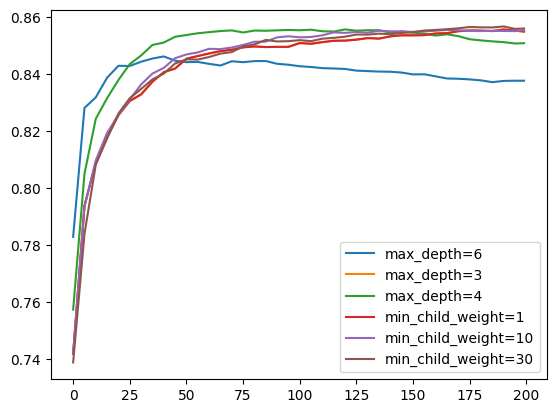

In [166]:
for min_child_weight, df_score in scores.items():
    plt.plot(df_score.num_iter, df_score.val_auc, label=min_child_weight)

#plt.ylim(0.82, 0.84)
plt.legend()

### <b>Train Final Model</b>

In [167]:
xgb_params = {
    'eta': 0.1,
    'max_depth': 3,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
    
}

model = xgb.train(xgb_params, dtrain, num_boost_round=175)

In [168]:
xgb_params = {
    'eta': 0.1,
    'max_depth': 3,
    'min_child_weight': 30,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
    
}

model = xgb.train(xgb_params, dtrain, num_boost_round=175)

### <b>Selecting the Final Model</b>

* Retrain the best model of each type

##### <b>Retrain the best Decision Tree model we had </b>

In [169]:
df = DecisionTreeClassifier(max_depth=6, min_samples_leaf=15)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",15
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

##### <b>Retrain the best Random Forest model we had </b>

In [170]:
rf = RandomForestClassifier(n_estimators=200,
                            max_depth=10,
                            min_samples_leaf=3,
                            random_state=1)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

##### <b>Retrain the best XGBoost model we had </b>

In [171]:
xgb_params = {
    'eta': 0.1,
    'max_depth': 3,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
    
}

model = xgb.train(xgb_params, dtrain, num_boost_round=175)

### <b>Evaluate all the best of Models on Validation Data</b>

In [172]:
#Decision Tree
y_pred = dt.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)

0.7910121943514247

In [173]:
#Random Forest
y_pred = rf.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)

0.8476021987742465

In [174]:
#XGBoost Model
y_pred = model.predict(dval)
roc_auc_score(y_val, y_pred)

0.8550325393315221

### <b>Training the Final Model</b>
* To train the final model, we will use the entire dataset. Following the training, we will evaluate the final model on our test dataset.

In [175]:
df_train_full

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
95,ok,3,owner,36,41,married,no,freelance,75,200.0,3000.0,0.0,1000,1000
3042,ok,10,other,60,50,single,no,fixed,35,147.0,0.0,0.0,1080,1152
2781,ok,8,private,48,31,married,no,fixed,60,122.0,4000.0,0.0,1400,1732
4453,ok,5,owner,60,32,married,no,freelance,60,140.0,4000.0,1000.0,1350,1650
240,default,13,rent,24,49,married,no,freelance,90,0.0,0.0,0.0,700,800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4426,ok,34,owner,60,50,married,yes,fixed,60,150.0,9000.0,0.0,1300,1700
466,default,2,rent,60,46,separated,no,fixed,49,136.0,0.0,0.0,1500,1687
3092,ok,20,owner,60,54,married,no,fixed,60,191.0,5000.0,0.0,600,1400
3772,default,3,private,36,38,divorced,yes,fixed,35,0.0,12500.0,0.0,3000,4800


In [176]:
df_train_full = df_train_full.reset_index(drop=True)

In [177]:
y_train_full = (df_train_full.status=='default').astype(int).values
y_train_full

array([0, 0, 0, ..., 0, 1, 0], shape=(3563,))

In [178]:
del df_train_full['status']

In [179]:
dicts_full_train = df_train_full.to_dict(orient='records')

dv = DictVectorizer(sparse=False)
X_full_train = dv.fit_transform(dicts_full_train)

dicts_test = df_test.to_dict(orient='records')
X_test = dv.transform(dicts_test)

In [180]:
feature_names = list(dv.get_feature_names_out())
feature_names

['age',
 'amount',
 'assets',
 'debt',
 'expenses',
 'home=ignore',
 'home=other',
 'home=owner',
 'home=parents',
 'home=private',
 'home=rent',
 'home=unknown',
 'income',
 'job=fixed',
 'job=freelance',
 'job=others',
 'job=partime',
 'job=unknown',
 'marital=divorced',
 'marital=married',
 'marital=separated',
 'marital=single',
 'marital=widow',
 'price',
 'records=no',
 'records=yes',
 'seniority',
 'time']

* XGBoost models require data in the form of DMatrix for training. We also prepare the test data, which doesn’t require labels, as we’ll evaluate it using Scikit-Learn.

In [181]:
feature_names = list(dv.get_feature_names_out())
dfulltrain = xgb.DMatrix(X_full_train, 
                         label=y_train_full,
                         feature_names=feature_names)
dtest = xgb.DMatrix(X_test, feature_names=feature_names)

* Now let’s set the parameters and train the final model.

In [182]:
xgb_params = {
    'eta': 0.1,
    'max_depth': 3,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
    
}

model = xgb.train(xgb_params, dfulltrain, num_boost_round=175)

### <b>Evaluate the Final Model</b>

In [183]:
y_pred = model.predict(dtest)
roc_auc_score(y_test, y_pred)

0.8473429951690821

* The performance of the final model is a little bit worse than the best XGBoost model (0.855), but it’s only like a fraction of one percent. So this is fine.
* We can conclude that our model didn’t overfit. The final model generalizes quite well on unseen data.
* XGBoost models are often one of the best models at least for tabular data (dataframe with features).
* The downside of this is that XGBoost models are more complex, it’s more difficult to tune, it has more parameters, and it’s easier to overfit with XGBoost.